# Supervised learning

## Task 1. Answer the questions
* Derive an analytical solution to the regression problem. Use a vector form of the equation.

    https://deepmachinelearning.ru/docs/Machine-learning/Linear-regression-extensions/Analytic-solution

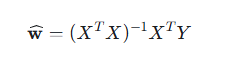

* What changes in the solution when L1 and L2 regularizations are added to the loss function.

  L1:<br>
  There is no closed-form analytical solution for L1 regularization, so it is necessary to use numerical methods to find a solution, for example, <b>gradient descent</b>.
  
  L2:<br>
  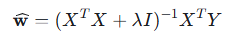

* Explain why L1 regularization is often used to select features. Why are there many weights equal to 0 after the model is fit?

  The task is to find the minimum of the loss function, so L1 regularization pushes the weights to zero with equal force, since the gradient along it is a <b>constant</b>. Therefore, for a <b>sufficiently large λ</b> in L1 regularization, it will exactly set some of the weights equal to zero.  Thus, with L1 regularization, <b>the most important features</b> can be identified.


* Explain how you can use the same models (Linear regression, Ridge, etc.) but make it possible to fit nonlinear dependencies.

  Using <b>basic functions</b> or <b>polynomial features</b> and transform the features of the model.

## Task 2. Introduction — make all the preprocessing staff from the previous lesson

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, root_mean_squared_error
from sklearn.preprocessing import StandardScaler, MinMaxScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet

In [ ]:
train = pd.read_json('data/train.json')
test = pd.read_json('data/test.json')

In [ ]:
low_train, high_train = np.percentile(train['price'], [1, 99])
low_test, high_test = np.percentile(test['price'], [1, 99])

train = train[(train['price'] >= low_train) & (train['price'] <= high_train)]
test = test[(test['price'] >= low_test) & (test['price'] <= high_test)]

In [ ]:
low_bath, high_bath = np.percentile(test['bathrooms'], [1, 99])
test = test[(test['bathrooms'] >= low_bath) & (test['bathrooms'] <= high_bath)]

## Task 3. Intro data analysis part 2
* Let's generate additional features for better model quality. Consider a column called "Features". It consists of a list of highlights of the current flat.
* Remove unused symbols ([,], ', ", and space) from the column.

In [ ]:
train.features = train.features.apply(lambda x: ','.join(x).replace(' ', ''))
test.features = test.features.apply(lambda x: ','.join(x).replace(' ', ''))

* Get all values in each list and collect the result in one huge list for the whole dataset. You can use DataFrame.iterrows().

In [ ]:
features_list = []

for _, row in train.iterrows():
  curr = row.features.split(',')
  if curr != ['']:
    features_list.extend(curr)

* How many unique values does a result list contain?
* Let's get acquainted with the new library — Collections. With this package you could effectively get quantity statistics about your data.

In [ ]:
counter = Counter(features_list)
unique_list = list(counter.keys())

### Unique count

In [ ]:
len(unique_list)

1531

### 10 most common

In [ ]:
counter.most_common(10)

[('Elevator', 25398),
 ('HardwoodFloors', 23159),
 ('CatsAllowed', 23148),
 ('DogsAllowed', 21662),
 ('Doorman', 20497),
 ('Dishwasher', 20095),
 ('NoFee', 17806),
 ('LaundryinBuilding', 16093),
 ('FitnessCenter', 13000),
 ('Pre-War', 8978)]

### 20 Most common
* If everything is correct, you should get next values: 'Elevator', 'CatsAllowed', 'HardwoodFloors', 'DogsAllowed', 'Doorman', 'Dishwasher', 'NoFee', 'LaundryinBuilding', 'FitnessCenter', 'Pre-War', 'LaundryinUnit', 'RoofDeck', 'OutdoorSpace', 'DiningRoom', 'HighSpeedInternet', 'Balcony', 'SwimmingPool', 'LaundryInBuilding', 'NewConstruction', 'Terrace'.

In [ ]:
counter.most_common(20)

[('Elevator', 25398),
 ('HardwoodFloors', 23159),
 ('CatsAllowed', 23148),
 ('DogsAllowed', 21662),
 ('Doorman', 20497),
 ('Dishwasher', 20095),
 ('NoFee', 17806),
 ('LaundryinBuilding', 16093),
 ('FitnessCenter', 13000),
 ('Pre-War', 8978),
 ('LaundryinUnit', 8448),
 ('RoofDeck', 6423),
 ('OutdoorSpace', 5137),
 ('DiningRoom', 4901),
 ('HighSpeedInternet', 4225),
 ('Balcony', 2898),
 ('SwimmingPool', 2648),
 ('LaundryInBuilding', 2565),
 ('NewConstruction', 2507),
 ('Terrace', 2179)]

* Now create 20 new features based on the top 20 values: 1 if the value is in the "Feature" column, otherwise 0.

In [ ]:
features = counter.most_common(20)
final_df = pd.DataFrame()

for f in features:
  final_df[f[0]] = train.features.apply(lambda x: int(f[0] in x.split(',')))

* Extend our feature set with 'bathrooms', 'bedrooms' and create a special variable feature_list with all feature names. Now we have 22 values. All models should be trained on these 22 features.

In [ ]:
final_df['bathrooms'] = train.bathrooms
final_df['bedrooms'] = train.bedrooms

feature_list = final_df.columns

In [ ]:
feature_list

Index(['Elevator', 'HardwoodFloors', 'CatsAllowed', 'DogsAllowed', 'Doorman',
       'Dishwasher', 'NoFee', 'LaundryinBuilding', 'FitnessCenter', 'Pre-War',
       'LaundryinUnit', 'RoofDeck', 'OutdoorSpace', 'DiningRoom',
       'HighSpeedInternet', 'Balcony', 'SwimmingPool', 'LaundryInBuilding',
       'NewConstruction', 'Terrace', 'bathrooms', 'bedrooms'],
      dtype='object')

In [ ]:
final_df.head()

,Elevator,HardwoodFloors,CatsAllowed,DogsAllowed,Doorman,Dishwasher,NoFee,LaundryinBuilding,FitnessCenter,Pre-War,...,OutdoorSpace,DiningRoom,HighSpeedInternet,Balcony,SwimmingPool,LaundryInBuilding,NewConstruction,Terrace,bathrooms,bedrooms
4,0,1,1,1,0,1,0,1,0,1,...,0,1,0,0,0,0,0,0,1.0,1
6,1,1,0,0,1,1,1,1,0,0,...,0,0,0,0,0,0,0,0,1.0,2
9,1,1,0,0,1,1,0,1,0,0,...,0,0,0,0,0,0,0,0,1.0,2
10,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1.5,3
15,1,0,0,0,1,0,0,1,1,0,...,0,0,0,0,0,0,0,0,1.0,0


## Task 4. Models implementation — Linear regression
* Implement a Python class for a linear regression algorithm with two basic methods — fit and predict. Use stochastic gradient descent (SGD) to find optimal model weights. For better understanding, we recommend implementing separate versions of the algorithm with the analytical solution and non-stochastic gradient descent under the hood.

### Stohastic gradient dscent
w:=w−α(−(yi−wxi)xi)=w+α(yi−wxi)xi

In [ ]:
class StochasticGradientDescent:
  def __init__(self):
    self.learning_rate = 0.00001
    self.epochs = 500
    self.weights = None

  def fit(self, X, y):
    """
    X (n_objects, n_features)
    y (n_objects,)
    """
    # X to np.array
    X = np.array(X)

    # y to np.array column
    y = np.array(y)

    n_objects, n_features = X.shape
    self.weights = np.zeros(n_features + 1)

    np.random.seed(21)

    for _ in range(self.epochs):
        indices = np.random.permutation(n_objects)

        for i in indices:
            xi = X[i]
            yi = y[i]

            # y_pred = w^T * x_i + b
            y_pred = np.dot(self.weights[1:], xi) + self.weights[0]

            # error (yi−wxi)
            error = yi - y_pred

            # w := w + α * (yi−wxi) * xi

            self.weights[1:] += self.learning_rate * error * xi

            self.weights[0] += self.learning_rate * error

  def predict(self, X):
    X = np.array(X)
    return np.dot(X, self.weights[1:]) + self.weights[0]

  def get_r2(self, y_true, y_pred):
    res = np.sum((y_true - y_pred)**2)
    total = np.sum((y_true - y_true.mean())**2)
    return 1 - (res / total)

### Non-stohastic gradient descent
https://www.geeksforgeeks.org/machine-learning/gradient-descent-in-linear-regression/

In [ ]:
class GradientDescent:
    def __init__(self, learning_rate=0.01, n_iterations=1000, tolerance=1e-6):
        self.learning_rate = learning_rate
        self.n_iterations = n_iterations
        self.tolerance = tolerance
        self.weights = None
        self.bias = None
        self.loss_history = []

    def fit(self, X, y):
        """
        X (n_objects, n_features)
        y (n_objects,)
        """
        # X to np.array
        X = np.array(X)

        # y to np.array column
        y = np.array(y)

        n_samples, n_features = X.shape

        self.weights = np.zeros(n_features)
        self.bias = 0

        for i in range(self.n_iterations):
            y_pred = np.dot(X, self.weights) + self.bias

            # MSE
            loss = np.mean((y_pred - y) ** 2)
            self.loss_history.append(loss)

            dw = (2 / n_samples) * np.dot(X.T, (y_pred - y))
            db = (2 / n_samples) * np.sum(y_pred - y)

            self.weights -= self.learning_rate * dw
            self.bias -= self.learning_rate * db

            if i > 0 and abs(self.loss_history[-2] - loss) < self.tolerance:
                break

        return self

    def predict(self, X):
        return np.dot(X, self.weights) + self.bias

### Analytical solution

In [ ]:
class AnalyticalSolution:
  def __init__(self, fit_intercept=True):
    self.fit_intercept = fit_intercept
    self.weights = None
    self.intercept_ = None
    self.coef_ = None

  def fit(self, X, y):
    """
    X (n_objects, n_features)
    y (n_objects,)
    """
    # X to np.array
    X = np.array(X)

    # y to np.array column
    y = np.array(y).reshape(-1, 1)

    # create column of ones and merge with original X
    if self.fit_intercept:
      X = np.hstack([np.ones((X.shape[0], 1)), X])

    try:
      XTX = X.T @ X
      XTX_inv = np.linalg.inv(XTX)

      self.weights = XTX_inv @ X.T @ y

    except np.linalg.LinAlgError:
      print('the matrix is singular')
      self.weights = np.linalg.pinv(X) @ y

    if self.fit_intercept:
      self.intercept_ = self.weights[0].item()
      self.coef_ = self.weights[1:].flatten()
    else:
      self.intercept_ = 0
      self.coef_ = self.weights.flatten()

    return self

  def predict(self, X):
    """
    X (n_objects, n_features)
    """

    # X to np.array
    X = np.array(X)

    # create column of ones and merge with original X
    if self.fit_intercept:
      X = np.hstack([np.ones((X.shape[0], 1)), X])

    return (X @ self.weights).flatten()

* What is determenistic model? Make SGD determenistic.

  My SGD model is already determenistic

* Define the R squared (R2) coefficient and implement a function to calculate it.

  https://www.geeksforgeeks.org/machine-learning/how-to-calculate-r2-with-scikit-learn/
  
  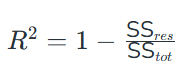

In [ ]:
def get_r2(y_true, y_pred):
  res = np.sum((y_true - y_pred)**2)
  total = np.sum((y_true - y_true.mean())**2)
  return 1 - (res / total)

* Make predictions with your algorithm and estimate the model with MAE, RMSE and R2 metrics.

In [ ]:
X = final_df
y = train.price

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=21)

In [ ]:
model = StochasticGradientDescent()

model.fit(X_train, y_train)

y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

### R2

In [ ]:
model.get_r2(y_test, y_pred_test).item()

0.5859317158367681

### MAE

In [ ]:
mean_absolute_error(y_test, y_pred_test)

708.0551901902037

### RMSE

In [ ]:
root_mean_squared_error(y_test, y_pred_test)

1025.9450689697173

* Initialize LinearRegression() from sklearn.linear_model, fit the model, and predict the training and test parts as in the previous lesson.

In [ ]:
lr_model = LinearRegression()

lr_model.fit(X_train, y_train)

y_pred_train_lr = lr_model.predict(X_train)
y_pred_test_lr = lr_model.predict(X_test)

### R2

In [ ]:
get_r2(y_train, y_pred_train).item()

0.5785038151797597

In [ ]:
get_r2(y_test, y_pred_test).item()

0.5858949371672871

### MAE

In [ ]:
mean_absolute_error(y_train, y_pred_train)

713.5553592183991

In [ ]:
mean_absolute_error(y_test, y_pred_test)

708.5544953595517

### RMSE

In [ ]:
root_mean_squared_error(y_train, y_pred_train)

1037.7643090792808

In [ ]:
root_mean_squared_error(y_test, y_pred_test)

1025.9906315715791

* Compare the quality metrics and make sure the difference is small (between your implementations and sklearn).
* Store the metrics as in the previous lesson in a table with columns model, train, test for MAE table, RMSE table, and R2 coefficient.

In [ ]:
r2_df = pd.DataFrame({
    'model': ['my_lr', 'sklearn_lr'],
    'train': [model.get_r2(y_train, y_pred_train).item(), get_r2(y_train, y_pred_train_lr).item()],
    'test': [model.get_r2(y_test, y_pred_test).item(), get_r2(y_test, y_pred_test_lr).item()],
})

r2_df

,model,train,test
0,my_lr,0.578498,0.585932
1,sklearn_lr,0.578504,0.585895


In [ ]:
mae_df = pd.DataFrame({
    'model': ['my_lr', 'sklearn_lr'],
    'train': [mean_absolute_error(y_train, y_pred_train), mean_absolute_error(y_train, y_pred_train_lr)],
    'test': [mean_absolute_error(y_test, y_pred_test), mean_absolute_error(y_test, y_pred_test_lr)],
})

mae_df

,model,train,test
0,my_lr,713.079445,708.055190
1,sklearn_lr,713.555359,708.554495


In [ ]:
rmse_df = pd.DataFrame({
    'model': ['my_lr', 'sklearn_lr'],
    'train': [root_mean_squared_error(y_train, y_pred_train), root_mean_squared_error(y_train, y_pred_train_lr)],
    'test': [root_mean_squared_error(y_test, y_pred_test), root_mean_squared_error(y_test, y_pred_test_lr)],
})

rmse_df

,model,train,test
0,my_lr,1037.771193,1025.945069
1,sklearn_lr,1037.764309,1025.990632


## Task 5. Regularized models implementation — Ridge, Lasso, ElasticNet
* Implement Ridge, Lasso, ElasticNet algorithms: extend the loss function with L2, L1 and both regularizations accordingly.

## Ridge, Lasso, ElasticNet

In [ ]:
class MyElasticNet:
  def __init__(self, learning_rate=0.00001, epochs=500, lambda_=0.1, l1_ratio=0.5):
    self.learning_rate = learning_rate
    self.epochs = epochs
    self.lambda_ = lambda_
    self.l1_ratio = l1_ratio
    self.weights = None

  def fit(self, X, y):
    """
    X (n_objects, n_features)
    y (n_objects,)
    """
    # X to np.array
    X = np.array(X)

    # y to np.array column
    y = np.array(y)

    n_objects, n_features = X.shape
    self.weights = np.zeros(n_features + 1)

    np.random.seed(21)

    for _ in range(self.epochs):
        indices = np.random.permutation(n_objects)

        for i in indices:
            xi = X[i]
            yi = y[i]

            # y_pred = w^T * x_i + b
            y_pred = np.dot(self.weights[1:], xi) + self.weights[0]

            # error (yi−wxi)
            error = yi - y_pred

            self.weights[0] += self.learning_rate * error

            # Lasso
            sign_weights = np.sign(self.weights[1:])
            l1_gradient = self.lambda_ * self.l1_ratio * sign_weights

            # Ridge
            l2_gradient = self.lambda_ * (1 - self.l1_ratio) * 2 * self.weights[1:]

            # Elastic
            self.weights[1:] += self.learning_rate * (error * xi - l1_gradient - l2_gradient)

  def predict(self, X):
    X = np.array(X)
    return np.dot(X, self.weights[1:]) + self.weights[0]

* Make predictions with your algorithm and estimate the model with MAE, RMSE and R2 metrics.

In [ ]:
lasso_lr = MyElasticNet(l1_ratio=1)
rigde_lr = MyElasticNet(l1_ratio=0)
elastic_lr = MyElasticNet()

In [ ]:
lasso_lr.fit(X_train, y_train)

In [ ]:
rigde_lr.fit(X_train, y_train)

In [ ]:
elastic_lr.fit(X_train, y_train)

### MAE

In [ ]:
y_pred = {
    'lasso': [lasso_lr.predict(X_train), lasso_lr.predict(X_test)],
    'ridge': [rigde_lr.predict(X_train), rigde_lr.predict(X_test)],
    'elastic': [elastic_lr.predict(X_train), elastic_lr.predict(X_test)]
}

mae_results = {
    'model': [],
    'train': [],
    'test': []
}

for key, value in y_pred.items():
  mae_results['model'].append(key)
  mae_results['train'].append(mean_absolute_error(y_train, value[0]))
  mae_results['test'].append(mean_absolute_error(y_test, value[1]))

mae_df = pd.DataFrame(mae_results)

mae_df

,model,train,test
0,lasso,713.012869,707.976023
1,ridge,753.949887,741.434584
2,elastic,729.976795,719.362565


### RMSE

In [ ]:
rmse_results = {
    'model': [],
    'train': [],
    'test': []
}

for key, value in y_pred.items():
  rmse_results['model'].append(key)
  rmse_results['train'].append(root_mean_squared_error(y_train, value[0]))
  rmse_results['test'].append(root_mean_squared_error(y_test, value[1]))

rmse_df = pd.DataFrame(rmse_results)

rmse_df

,model,train,test
0,lasso,1037.774575,1025.904485
1,ridge,1113.818880,1096.558688
2,elastic,1074.299661,1057.727666


### R2

In [ ]:
r2_results = {
    'model': [],
    'train': [],
    'test': []
}

for key, value in y_pred.items():
  r2_results['model'].append(key)
  r2_results['train'].append(get_r2(y_train, value[0]).item())
  r2_results['test'].append(get_r2(y_test, value[1]).item())

r2_df = pd.DataFrame(r2_results)

r2_df

,model,train,test
0,lasso,0.578495,0.585964
1,ridge,0.514460,0.526971
2,elastic,0.548303,0.559880


* Initialize Ridge(), Lasso(), and ElasticNet() from sklearn.linear_model, fit the model, and make predictions for the training and test samples as in the previous lesson.

In [ ]:
sklearn_ridge = Ridge()
sklearn_lasso = Lasso()
sklearn_elsactic = ElasticNet()

In [ ]:
sklearn_ridge.fit(X_train, y_train)

Ridge()

In [ ]:
sklearn_lasso.fit(X_train, y_train)

Lasso()

In [ ]:
sklearn_elsactic.fit(X_train, y_train)

ElasticNet()

In [ ]:
y_pred_sklearn = {
    'sklearn_lasso': [sklearn_lasso.predict(X_train), sklearn_lasso.predict(X_test)],
    'sklearn_ridge': [sklearn_ridge.predict(X_train), sklearn_ridge.predict(X_test)],
    'sklearn_elastic': [sklearn_elsactic.predict(X_train), sklearn_elsactic.predict(X_test)]
}

sklearn_mae_results = {
    'model': [],
    'train': [],
    'test': []
}

for key, value in y_pred_sklearn.items():
  sklearn_mae_results['model'].append(key)
  sklearn_mae_results['train'].append(mean_absolute_error(y_train, value[0]))
  sklearn_mae_results['test'].append(mean_absolute_error(y_test, value[1]))

sklearn_mae_df = pd.DataFrame(sklearn_mae_results)

sklearn_mae_df

,model,train,test
0,sklearn_lasso,713.090455,707.952405
1,sklearn_ridge,713.551422,708.546985
2,sklearn_elastic,810.026107,796.203619


In [ ]:
sklearn_rmse_results = {
    'model': [],
    'train': [],
    'test': []
}

for key, value in y_pred_sklearn.items():
  sklearn_rmse_results['model'].append(key)
  sklearn_rmse_results['train'].append(root_mean_squared_error(y_train, value[0]))
  sklearn_rmse_results['test'].append(root_mean_squared_error(y_test, value[1]))

sklearn_rmse_df = pd.DataFrame(sklearn_rmse_results)

sklearn_rmse_df

,model,train,test
0,sklearn_lasso,1037.961358,1025.744708
1,sklearn_ridge,1037.764318,1025.987289
2,sklearn_elastic,1193.388191,1177.039795


In [ ]:
sklearn_r2_results = {
    'model': [],
    'train': [],
    'test': []
}

for key, value in y_pred_sklearn.items():
  sklearn_r2_results['model'].append(key)
  sklearn_r2_results['train'].append(get_r2(y_train, value[0]).item())
  sklearn_r2_results['test'].append(get_r2(y_test, value[1]).item())

sklearn_r2_df = pd.DataFrame(sklearn_r2_results)

sklearn_r2_df

,model,train,test
0,sklearn_lasso,0.578344,0.586093
1,sklearn_ridge,0.578504,0.585898
2,sklearn_elastic,0.442609,0.454988


* Compare quality metrics and make sure the difference is small (between your implementations and sklearn).
* Store the metrics as in the previous lesson in a table with columns model, train, test for MAE table, RMSE table, and R2 coefficient.

### MAE

In [ ]:
all_mae_results = pd.concat([mae_df, sklearn_mae_df], axis=0)

all_mae_results

,model,train,test
0,lasso,713.012869,707.976023
1,ridge,753.949887,741.434584
2,elastic,729.976795,719.362565
0,sklearn_lasso,713.090455,707.952405
1,sklearn_ridge,713.551422,708.546985
2,sklearn_elastic,810.026107,796.203619


### RMSE

In [ ]:
all_rmse_results = pd.concat([rmse_df, sklearn_rmse_df], axis=0)

all_rmse_results

,model,train,test
0,lasso,1037.774575,1025.904485
1,ridge,1113.818880,1096.558688
2,elastic,1074.299661,1057.727666
0,sklearn_lasso,1037.961358,1025.744708
1,sklearn_ridge,1037.764318,1025.987289
2,sklearn_elastic,1193.388191,1177.039795


### R2

In [ ]:
all_r2_results = pd.concat([r2_df, sklearn_r2_df], axis=0)

all_r2_results

,model,train,test
0,lasso,0.578495,0.585964
1,ridge,0.514460,0.526971
2,elastic,0.548303,0.559880
0,sklearn_lasso,0.578344,0.586093
1,sklearn_ridge,0.578504,0.585898
2,sklearn_elastic,0.442609,0.454988


## Task 6. Feature normalization
* First, write several examples of why and where feature normalization is mandatory and vice versa.

  Answer:
  - Data normalization is <b>mandatory</b> in cases where objects vary <b>greatly in scale</b>, algorithms are <b>sensitive to the scale</b> of features, and the data distribution is <b>not Gaussian</b>.

  - Normalization of data is <b>not necessary</b> when the data has a <b>natural hierarchy</b> of importance of features, the data contains rare but <b>important anomalies</b>.



  * Let's consider the first of the classical normalization methods — MinMaxScaler. Write a mathematical formula for this method.

  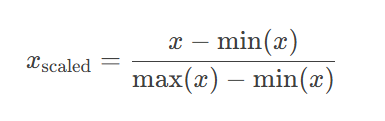

* Implement your own function or class for MinMaxScaler feature normalization.

  https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.MinMaxScaler.html

  X_std = (X - X.min(axis=0)) / (X.max(axis=0) - X.min(axis=0))


  X_scaled = X_std * (max - min) + min

In [ ]:
class MyMinMaxScaler:
  def __init__(self, feature_range=(0, 1)):
    self.feature_range = feature_range
    self.min_ = None
    self.max_ = None
    self.data_min_ = None
    self.data_max_ = None

  def fit(self, X, y=None):
    X = np.array(X)
    self.data_min_ = X.min(axis=0)
    self.data_max_ = X.max(axis=0)

    self.min_ = self.feature_range[0]
    self.max_ = self.feature_range[1]

    return self

  def transform(self, X):
    X = np.array(X)

    range_ = self.data_max_ - self.data_min_
    range_[range_ == 0] = 1.0

    X_std = (X - self.data_min_) / range_

    X_scaled = X_std * (self.max_ - self.min_) + self.min_

    return X_scaled

  def fit_transform(self, X, y=None):
    self.fit(X)
    return self.transform(X)

* Initialize MinMaxScaler() from sklearn.preprocessing.
* Compare the feature normalization with your own method and with sklearn.

In [ ]:
my_scaler = MyMinMaxScaler()
sklearn_scaler = MinMaxScaler()

my_scaled = my_scaler.fit_transform(X)
sklearn_scaled = sklearn_scaler.fit_transform(X)

np.allclose(my_scaled, sklearn_scaled)

True

* Repeat the steps from b to e for another normalization method StandardScaler.


  Math formula:

  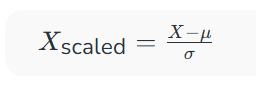

  <b>X</b> is the original value


  <b>μ</b> is the mean of the feature


  <b>σ</b> is the standard deviation

In [ ]:
class MyStandardScaler:
  def __init__(self):
    self.std_ = None
    self.mean_ = None

  def fit(self, X, y=None):
    X = np.array(X)

    self.std_ = X.std(axis=0)
    self.std_[self.std_ == 0] = 1.0

    self.mean_ = X.mean(axis=0)

    return self

  def transform(self, X):
    X = np.array(X)

    X_scaled = (X - self.mean_) / self.std_

    return X_scaled

  def fit_transform(self, X, y=None):
    self.fit(X)
    return self.transform(X)

In [ ]:
my_scaler = MyStandardScaler()
sklearn_scaler = StandardScaler()

my_scaled = my_scaler.fit_transform(X)
sklearn_scaled = sklearn_scaler.fit_transform(X)

np.allclose(my_scaled, sklearn_scaled)

True

## Task 7. Fit custom and sklearn models with normalized data
* Fit all models — Linear Regression, Ridge, Lasso, and ElasticNet — with MinMaxScaler.

In [ ]:
all_mae_results.to_csv('data/mae.csv', index=False)

In [ ]:
all_rmse_results.to_csv('data/rmse.csv', index=False)

In [ ]:
all_r2_results.to_csv('data/r2.csv', index=False)

In [ ]:
scaler = MyMinMaxScaler()
X_min_max = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_min_max, y, test_size=0.2, random_state=21)

### My models MinMax

In [ ]:
lr = StochasticGradientDescent()
lasso_lr = MyElasticNet(l1_ratio=1)
ridge_lr = MyElasticNet(l1_ratio=0)
elastic_lr = MyElasticNet()

In [ ]:
lr.fit(X_train, y_train)

In [ ]:
lasso_lr.fit(X_train, y_train)

In [ ]:
ridge_lr.fit(X_train, y_train)

In [ ]:
elastic_lr.fit(X_train, y_train)

In [ ]:
y_pred = {
    'my_lr_min_max': [lr.predict(X_train), lr.predict(X_test)],
    'my_lasso_min_max': [lasso_lr.predict(X_train), lasso_lr.predict(X_test)],
    'my_ridge_min_max': [ridge_lr.predict(X_train), ridge_lr.predict(X_test)],
    'my_elastic_min_max': [elastic_lr.predict(X_train), elastic_lr.predict(X_test)]
}


min_max_mae_results = {
    'model': [],
    'train': [],
    'test': []
}

for key, value in y_pred.items():
  min_max_mae_results['model'].append(key)
  min_max_mae_results['train'].append(mean_absolute_error(y_train, value[0]))
  min_max_mae_results['test'].append(mean_absolute_error(y_test, value[1]))

min_max_mae_df = pd.DataFrame(min_max_mae_results)

min_max_mae_df

,model,train,test
0,my_lr_min_max,766.920031,759.124505
1,my_lasso_min_max,766.915415,759.077978
2,my_ridge_min_max,1018.366465,1012.739116
3,my_elastic_min_max,977.430330,972.374243


In [ ]:
min_max_rmse_results = {
    'model': [],
    'train': [],
    'test': []
}

for key, value in y_pred.items():
  min_max_rmse_results['model'].append(key)
  min_max_rmse_results['train'].append(root_mean_squared_error(y_train, value[0]))
  min_max_rmse_results['test'].append(root_mean_squared_error(y_test, value[1]))

min_max_rmse_df = pd.DataFrame(min_max_rmse_results)

min_max_rmse_df

,model,train,test
0,my_lr_min_max,1118.913482,1111.142245
1,my_lasso_min_max,1119.109157,1111.308912
2,my_ridge_min_max,1443.226367,1440.464186
3,my_elastic_min_max,1394.412792,1392.569925


In [ ]:
min_max_r2_results = {
    'model': [],
    'train': [],
    'test': []
}

for key, value in y_pred.items():
  min_max_r2_results['model'].append(key)
  min_max_r2_results['train'].append(get_r2(y_train, value[0]).item())
  min_max_r2_results['test'].append(get_r2(y_test, value[1]).item())

min_max_r2_df = pd.DataFrame(min_max_r2_results)

min_max_r2_df

,model,train,test
0,my_lr_min_max,0.510008,0.514306
1,my_lasso_min_max,0.509836,0.514160
2,my_ridge_min_max,0.184798,0.183740
3,my_elastic_min_max,0.239010,0.237117


In [ ]:
all_mae_results = pd.concat([all_mae_results, min_max_mae_df], axis=0)

all_mae_results

,model,train,test
0,lasso,713.012869,707.976023
1,ridge,753.949887,741.434584
2,elastic,729.976795,719.362565
0,sklearn_lasso,713.090455,707.952405
1,sklearn_ridge,713.551422,708.546985
2,sklearn_elastic,810.026107,796.203619
0,my_lr_min_max,766.920031,759.124505
1,my_lasso_min_max,766.915415,759.077978
2,my_ridge_min_max,1018.366465,1012.739116
3,my_elastic_min_max,977.430330,972.374243


In [ ]:
all_rmse_results = pd.concat([all_rmse_results, min_max_rmse_df], axis=0)

all_rmse_results

,model,train,test
0,lasso,1037.774575,1025.904485
1,ridge,1113.818880,1096.558688
2,elastic,1074.299661,1057.727666
0,sklearn_lasso,1037.961358,1025.744708
1,sklearn_ridge,1037.764318,1025.987289
2,sklearn_elastic,1193.388191,1177.039795
0,my_lr_min_max,1118.913482,1111.142245
1,my_lasso_min_max,1119.109157,1111.308912
2,my_ridge_min_max,1443.226367,1440.464186
3,my_elastic_min_max,1394.412792,1392.569925


In [ ]:
all_r2_results = pd.concat([all_r2_results, min_max_r2_df], axis=0)

all_r2_results

,model,train,test
0,lasso,0.578495,0.585964
1,ridge,0.514460,0.526971
2,elastic,0.548303,0.559880
0,sklearn_lasso,0.578344,0.586093
1,sklearn_ridge,0.578504,0.585898
2,sklearn_elastic,0.442609,0.454988
0,my_lr_min_max,0.510008,0.514306
1,my_lasso_min_max,0.509836,0.514160
2,my_ridge_min_max,0.184798,0.183740
3,my_elastic_min_max,0.239010,0.237117


### Sklearn models MinMax

In [ ]:
sklearn_lr = LinearRegression()
sklearn_ridge = Ridge()
sklearn_lasso = Lasso()
sklearn_elsactic = ElasticNet()

In [ ]:
sklearn_lr.fit(X_train, y_train)
sklearn_ridge.fit(X_train, y_train)
sklearn_lasso.fit(X_train, y_train)
sklearn_elsactic.fit(X_train, y_train)

ElasticNet()

In [ ]:
y_pred = {
    'sklearn_lr_min_max': [sklearn_lr.predict(X_train), sklearn_lr.predict(X_test)],
    'sklearn_lasso_min_max': [sklearn_lasso.predict(X_train), sklearn_lasso.predict(X_test)],
    'sklearn_ridge_min_max': [sklearn_ridge.predict(X_train), sklearn_ridge.predict(X_test)],
    'sklearn_elastic_min_max': [sklearn_elsactic.predict(X_train), sklearn_elsactic.predict(X_test)]
}


min_max_mae_results = {
    'model': [],
    'train': [],
    'test': []
}

for key, value in y_pred.items():
  min_max_mae_results['model'].append(key)
  min_max_mae_results['train'].append(mean_absolute_error(y_train, value[0]))
  min_max_mae_results['test'].append(mean_absolute_error(y_test, value[1]))

min_max_mae_df = pd.DataFrame(min_max_mae_results)

min_max_mae_df

,model,train,test
0,sklearn_lr_min_max,713.555359,708.554495
1,sklearn_lasso_min_max,713.439530,707.893086
2,sklearn_ridge_min_max,713.706452,708.511523
3,sklearn_elastic_min_max,1058.810039,1053.354751


In [ ]:
min_max_rmse_results = {
    'model': [],
    'train': [],
    'test': []
}

for key, value in y_pred.items():
  min_max_rmse_results['model'].append(key)
  min_max_rmse_results['train'].append(root_mean_squared_error(y_train, value[0]))
  min_max_rmse_results['test'].append(root_mean_squared_error(y_test, value[1]))

min_max_rmse_df = pd.DataFrame(min_max_rmse_results)

min_max_rmse_df

,model,train,test
0,sklearn_lr_min_max,1037.764309,1025.990632
1,sklearn_lasso_min_max,1038.189544,1025.987282
2,sklearn_ridge_min_max,1037.815039,1026.055798
3,sklearn_elastic_min_max,1492.975336,1489.161747


In [ ]:
min_max_r2_results = {
    'model': [],
    'train': [],
    'test': []
}

for key, value in y_pred.items():
  min_max_r2_results['model'].append(key)
  min_max_r2_results['train'].append(get_r2(y_train, value[0]).item())
  min_max_r2_results['test'].append(get_r2(y_test, value[1]).item())

min_max_r2_df = pd.DataFrame(min_max_r2_results)

min_max_r2_df

,model,train,test
0,sklearn_lr_min_max,0.578504,0.585895
1,sklearn_lasso_min_max,0.578158,0.585898
2,sklearn_ridge_min_max,0.578463,0.585842
3,sklearn_elastic_min_max,0.127629,0.127616


In [ ]:
all_mae_results = pd.concat([all_mae_results, min_max_mae_df], axis=0)
all_rmse_results = pd.concat([all_rmse_results, min_max_rmse_df], axis=0)
all_r2_results = pd.concat([all_r2_results, min_max_r2_df], axis=0)

### My Models StandardScaler

In [ ]:
scaler = MyStandardScaler()
X_standard = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_standard, y, test_size=0.2, random_state=21)

In [ ]:
lr.fit(X_train, y_train)

In [ ]:
lasso_lr.fit(X_train, y_train)

In [ ]:
ridge_lr.fit(X_train, y_train)

In [ ]:
elastic_lr.fit(X_train, y_train)

In [ ]:
y_pred = {
    'my_lr_standard': [lr.predict(X_train), lr.predict(X_test)],
    'my_lasso_standard': [lasso_lr.predict(X_train), lasso_lr.predict(X_test)],
    'my_ridge_standard': [ridge_lr.predict(X_train), ridge_lr.predict(X_test)],
    'my_elastic_standard': [elastic_lr.predict(X_train), elastic_lr.predict(X_test)]
}


standard_mae_results = {
    'model': [],
    'train': [],
    'test': []
}

for key, value in y_pred.items():
  standard_mae_results['model'].append(key)
  standard_mae_results['train'].append(mean_absolute_error(y_train, value[0]))
  standard_mae_results['test'].append(mean_absolute_error(y_test, value[1]))

standard_mae_df = pd.DataFrame(standard_mae_results)

standard_mae_df

,model,train,test
0,my_lr_standard,713.455359,708.471354
1,my_lasso_standard,713.430574,708.439998
2,my_ridge_standard,719.039016,710.295851
3,my_elastic_standard,714.143237,707.120610


In [ ]:
standard_rmse_results = {
    'model': [],
    'train': [],
    'test': []
}

for key, value in y_pred.items():
  standard_rmse_results['model'].append(key)
  standard_rmse_results['train'].append(root_mean_squared_error(y_train, value[0]))
  standard_rmse_results['test'].append(root_mean_squared_error(y_test, value[1]))

standard_rmse_df = pd.DataFrame(standard_rmse_results)

standard_rmse_df

,model,train,test
0,my_lr_standard,1037.769778,1026.022678
1,my_lasso_standard,1037.770339,1026.005271
2,my_ridge_standard,1049.102048,1034.637656
3,my_elastic_standard,1041.222640,1027.824834


In [ ]:
standard_r2_results = {
    'model': [],
    'train': [],
    'test': []
}

for key, value in y_pred.items():
  standard_r2_results['model'].append(key)
  standard_r2_results['train'].append(get_r2(y_train, value[0]).item())
  standard_r2_results['test'].append(get_r2(y_test, value[1]).item())

standard_r2_df = pd.DataFrame(standard_r2_results)

standard_r2_df

,model,train,test
0,my_lr_standard,0.578499,0.585869
1,my_lasso_standard,0.578499,0.585883
2,my_ridge_standard,0.569244,0.578885
3,my_elastic_standard,0.575690,0.584413


In [ ]:
all_mae_results = pd.concat([all_mae_results, standard_mae_df], axis=0)
all_rmse_results = pd.concat([all_rmse_results, standard_rmse_df], axis=0)
all_r2_results = pd.concat([all_r2_results, standard_r2_df], axis=0)

### Sklearn Models Standard

In [ ]:
sklearn_lr.fit(X_train, y_train)
sklearn_ridge.fit(X_train, y_train)
sklearn_lasso.fit(X_train, y_train)
sklearn_elsactic.fit(X_train, y_train)

ElasticNet()

In [ ]:
y_pred = {
    'sklearn_lr_standard': [sklearn_lr.predict(X_train), sklearn_lr.predict(X_test)],
    'sklearn_lasso_standard': [sklearn_lasso.predict(X_train), sklearn_lasso.predict(X_test)],
    'sklearn_ridge_standard': [sklearn_ridge.predict(X_train), sklearn_ridge.predict(X_test)],
    'sklearn_elastic_standard': [sklearn_elsactic.predict(X_train), sklearn_elsactic.predict(X_test)]
}


standard_mae_results = {
    'model': [],
    'train': [],
    'test': []
}

for key, value in y_pred.items():
  standard_mae_results['model'].append(key)
  standard_mae_results['train'].append(mean_absolute_error(y_train, value[0]))
  standard_mae_results['test'].append(mean_absolute_error(y_test, value[1]))

standard_mae_df = pd.DataFrame(standard_mae_results)

standard_mae_df

,model,train,test
0,sklearn_lr_standard,713.555359,708.554495
1,sklearn_lasso_standard,713.342700,708.271535
2,sklearn_ridge_standard,713.554642,708.553149
3,sklearn_elastic_standard,744.193750,733.166848


In [ ]:
standard_rmse_results = {
    'model': [],
    'train': [],
    'test': []
}

for key, value in y_pred.items():
  standard_rmse_results['model'].append(key)
  standard_rmse_results['train'].append(root_mean_squared_error(y_train, value[0]))
  standard_rmse_results['test'].append(root_mean_squared_error(y_test, value[1]))

standard_rmse_df = pd.DataFrame(standard_rmse_results)

standard_rmse_df

,model,train,test
0,sklearn_lr_standard,1037.764309,1025.990632
1,sklearn_lasso_standard,1037.793578,1025.840956
2,sklearn_ridge_standard,1037.764309,1025.990090
3,sklearn_elastic_standard,1083.445276,1067.561133


In [ ]:
standard_r2_results = {
    'model': [],
    'train': [],
    'test': []
}

for key, value in y_pred.items():
  standard_r2_results['model'].append(key)
  standard_r2_results['train'].append(get_r2(y_train, value[0]).item())
  standard_r2_results['test'].append(get_r2(y_test, value[1]).item())

standard_r2_df = pd.DataFrame(standard_r2_results)

standard_r2_df

,model,train,test
0,sklearn_lr_standard,0.578504,0.585895
1,sklearn_lasso_standard,0.578480,0.586016
2,sklearn_ridge_standard,0.578504,0.585895
3,sklearn_elastic_standard,0.540580,0.551658


In [ ]:
all_mae_results = pd.concat([all_mae_results, standard_mae_df], axis=0)
all_rmse_results = pd.concat([all_rmse_results, standard_rmse_df], axis=0)
all_r2_results = pd.concat([all_r2_results, standard_r2_df], axis=0)

## Task 8. Overfit models
* Let's look at an overfitted model in practice. From theory, you know that polynomial regression is easy to overfit. So let's create a toy example and see how regularization works in real life.
* In the previous lesson, we created polynomial features with degree 10. Here we repeat these steps from the previous lesson, remembering that we have only 2 basic features — 'bathrooms' and 'bedrooms'.
* And train and fit all our implemented algorithms — Linear Regression, Ridge, Lasso, and ElasticNet — on a set of polynomial features.

In [ ]:
poly = PolynomialFeatures(10)
X_poly = poly.fit_transform(X[['bathrooms', 'bedrooms']])

min_max_scaler = MyMinMaxScaler()

X_poly_standard = min_max_scaler.fit_transform(X_poly)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_poly, y, test_size=0.2, random_state=21)

In [ ]:
lr.fit(X_train, y_train)

In [ ]:
lasso_lr.fit(X_train, y_train)

In [ ]:
ridge_lr.fit(X_train, y_train)

In [ ]:
elastic_lr.fit(X_train, y_train)

In [ ]:
y_pred = {
    'my_lr_poly': [lr.predict(X_train), lr.predict(X_test)],
    'my_lasso_poly': [lasso_lr.predict(X_train), lasso_lr.predict(X_test)],
    'my_ridge_poly': [ridge_lr.predict(X_train), ridge_lr.predict(X_test)],
    'my_elastic_poly': [elastic_lr.predict(X_train), elastic_lr.predict(X_test)]
}


poly_mae_results = {
    'model': [],
    'train': [],
    'test': []
}

for key, value in y_pred.items():
  poly_mae_results['model'].append(key)
  poly_mae_results['train'].append(mean_absolute_error(y_train, value[0]))
  poly_mae_results['test'].append(mean_absolute_error(y_test, value[1]))

poly_mae_df = pd.DataFrame(poly_mae_results)

poly_mae_df

,model,train,test
0,my_lr_poly,817.103072,807.072231
1,my_lasso_poly,817.258345,807.182745
2,my_ridge_poly,1077.431553,1072.204743
3,my_elastic_poly,1033.148793,1026.968139


In [ ]:
poly_rmse_results = {
    'model': [],
    'train': [],
    'test': []
}

for key, value in y_pred.items():
  poly_rmse_results['model'].append(key)
  poly_rmse_results['train'].append(root_mean_squared_error(y_train, value[0]))
  poly_rmse_results['test'].append(root_mean_squared_error(y_test, value[1]))

poly_rmse_df = pd.DataFrame(poly_rmse_results)

poly_rmse_df

,model,train,test
0,my_lr_poly,1186.952294,1166.543686
1,my_lasso_poly,1187.131510,1166.710298
2,my_ridge_poly,1519.919283,1512.526189
3,my_elastic_poly,1464.558968,1454.658117


In [ ]:
poly_r2_results = {
    'model': [],
    'train': [],
    'test': []
}

for key, value in y_pred.items():
  poly_r2_results['model'].append(key)
  poly_r2_results['train'].append(get_r2(y_train, value[0]).item())
  poly_r2_results['test'].append(get_r2(y_test, value[1]).item())

poly_r2_df = pd.DataFrame(poly_r2_results)

poly_r2_df

,model,train,test
0,my_lr_poly,0.448605,0.464665
1,my_lasso_poly,0.448439,0.464512
2,my_ridge_poly,0.095857,0.100027
3,my_elastic_poly,0.160521,0.167574


In [ ]:
all_mae_results = pd.concat([all_mae_results, poly_mae_df], axis=0)
all_rmse_results = pd.concat([all_rmse_results, poly_rmse_df], axis=0)
all_r2_results = pd.concat([all_r2_results, poly_r2_df], axis=0)

In [ ]:
all_mae_results.to_csv('data/mae.csv', index=False)
all_rmse_results.to_csv('data/rmse.csv', index=False)
all_r2_results.to_csv('data/r2.csv', index=False)

* Analyze the results and select the best model according to your opinion.

In [ ]:
all_mae_results.sort_values(by='test').head()

,model,train,test
3,my_elastic_standard,714.143237,707.120610
1,sklearn_lasso_min_max,713.439530,707.893086
0,sklearn_lasso,713.090455,707.952405
0,lasso,713.012869,707.976023
1,sklearn_lasso_standard,713.342700,708.271535


In [ ]:
all_rmse_results.sort_values(by='test').head()

,model,train,test
0,sklearn_lasso,1037.961358,1025.744708
1,sklearn_lasso_standard,1037.793578,1025.840956
0,lasso,1037.774575,1025.904485
1,sklearn_lasso_min_max,1038.189544,1025.987282
1,sklearn_ridge,1037.764318,1025.987289


In [ ]:
all_r2_results.sort_values(by='test', ascending=False).head()

,model,train,test
0,sklearn_lasso,0.578344,0.586093
1,sklearn_lasso_standard,0.578480,0.586016
0,lasso,0.578495,0.585964
1,sklearn_lasso_min_max,0.578158,0.585898
1,sklearn_ridge,0.578504,0.585898


## Task 9. Native models
* Calculate the mean and median metrics from the previous lesson and add the results to the final dataframe.

In [ ]:
predicted_mean_train = [y_train.mean()] * len(y_train)
predicted_mean_test = [y_test.mean()] * len(y_test)

predicted_median_train = [y_train.median()] * len(y_train)
predicted_median_test = [y_test.median()] * len(y_test)

# MAE
mean_mae_train = mean_absolute_error(y_train, predicted_mean_train)
mean_mae_test = mean_absolute_error(y_test, predicted_mean_test)

median_mae_train = mean_absolute_error(y_train, predicted_median_train)
median_mae_test = mean_absolute_error(y_test, predicted_median_test)

# RMSE
mean_rmse_train = root_mean_squared_error(y_train, predicted_mean_train)
mean_rmse_test = root_mean_squared_error(y_test, predicted_mean_test)

median_rmse_train = root_mean_squared_error(y_train, predicted_median_train)
median_rmse_test = root_mean_squared_error(y_test, predicted_median_test)

#R2
mean_r2_train = get_r2(y_train, predicted_mean_train).item()
mean_r2_test = get_r2(y_test, predicted_mean_test).item()

median_r2_train = get_r2(y_train, predicted_median_train).item()
median_r2_test = get_r2(y_test, predicted_median_test).item()

mae_df = pd.DataFrame({
    'model': ['mean', 'median'],
    'train': [mean_mae_train, median_mae_train],
    'test': [mean_mae_test, median_mae_test]
})

rmse_df = pd.DataFrame({
    'model': ['mean', 'median'],
    'train': [mean_rmse_train, median_rmse_train],
    'test': [mean_rmse_test, median_rmse_test]
})

r2_df = pd.DataFrame({
    'model': ['mean', 'median'],
    'train': [mean_r2_train, median_r2_train],
    'test': [mean_r2_test, median_r2_test]
})

all_mae_results = pd.concat([all_mae_results, mae_df], axis=0)
all_rmse_results = pd.concat([all_rmse_results, rmse_df], axis=0)
all_r2_results = pd.concat([all_r2_results, r2_df], axis=0)

In [ ]:
all_mae_results.to_csv('data/mae.csv', index=False)
all_rmse_results.to_csv('data/rmse.csv', index=False)
all_r2_results.to_csv('data/r2.csv', index=False)

## Task 10. Compare results
* Print your final tables
* What is the best model?
* Which is the most stable model?

In [ ]:
all_mae_results.sort_values(by='test')

,model,train,test
3,my_elastic_standard,714.143237,707.120610
1,sklearn_lasso_min_max,713.439530,707.893086
0,sklearn_lasso,713.090455,707.952405
0,lasso,713.012869,707.976023
1,sklearn_lasso_standard,713.342700,708.271535
1,my_lasso_standard,713.430574,708.439998
0,my_lr_standard,713.455359,708.471354
2,sklearn_ridge_min_max,713.706452,708.511523
1,sklearn_ridge,713.551422,708.546985
2,sklearn_ridge_standard,713.554642,708.553149


In [ ]:
all_rmse_results.sort_values(by='test')

,model,train,test
0,sklearn_lasso,1037.961358,1025.744708
1,sklearn_lasso_standard,1037.793578,1025.840956
0,lasso,1037.774575,1025.904485
1,sklearn_lasso_min_max,1038.189544,1025.987282
1,sklearn_ridge,1037.764318,1025.987289
2,sklearn_ridge_standard,1037.764309,1025.990090
0,sklearn_lr_standard,1037.764309,1025.990632
0,sklearn_lr_min_max,1037.764309,1025.990632
1,my_lasso_standard,1037.770339,1026.005271
0,my_lr_standard,1037.769778,1026.022678


In [ ]:
all_r2_results.sort_values(by='test', ascending=False)

,model,train,test
0,sklearn_lasso,0.578344,0.586093
1,sklearn_lasso_standard,0.578480,0.586016
0,lasso,0.578495,0.585964
1,sklearn_lasso_min_max,0.578158,0.585898
1,sklearn_ridge,0.578504,0.585898
2,sklearn_ridge_standard,0.578504,0.585895
0,sklearn_lr_standard,0.578504,0.585895
0,sklearn_lr_min_max,0.578504,0.585895
1,my_lasso_standard,0.578499,0.585883
0,my_lr_standard,0.578499,0.585869


Best model - <b>Lasso default</b>

The most stable - <b>Lasso</b>

## Task 11. Addition task
* There are some tricks with the target variable for better model quality. If we have a distribution with a heavy tail, you can use a monotone function to "improve" the distribution. In practice, you can use logarithmic functions. We recommend that you do this exercise and compare the results. But don't forget to do the inverse transformation if you want to compare metrics.